<a href="https://colab.research.google.com/github/AlanCamargo27/Atv-01_vendas_techstore/blob/main/Vendas_techstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ATV-01

In [1]:
from google.colab import files
uploaded = files.upload()

Saving vendas_techstore.csv to vendas_techstore.csv


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('vendas_techstore.csv')
df.head()

,vendedor,regiao,produto,valor,data
0,Rafael,Sudeste,Smartphone,2400.0,2026-01-04
1,Rafael,Sudeste,Fone Bluetooth,180.0,2026-01-11
2,Rafael,Sul,Carregador,60.0,2026-01-19
3,Juliana,Nordeste,Smart TV,1800.0,2026-01-07
4,Juliana,Nordeste,Smartphone,2500.0,2026-01-14


In [11]:
print("formato(linhas,colunas)", df.shape)
print("Tipos de cada coluna")
print(df.dtypes)

formato(linhas,colunas) (30, 5)
Tipos de cada coluna
vendedor     object
regiao       object
produto      object
valor       float64
data         object
dtype: object


In [13]:
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.to_period("M")
df.head()

,vendedor,regiao,produto,valor,data,mes
0,Rafael,Sudeste,Smartphone,2400.0,2026-01-04,2026-01
1,Rafael,Sudeste,Fone Bluetooth,180.0,2026-01-11,2026-01
2,Rafael,Sul,Carregador,60.0,2026-01-19,2026-01
3,Juliana,Nordeste,Smart TV,1800.0,2026-01-07,2026-01
4,Juliana,Nordeste,Smartphone,2500.0,2026-01-14,2026-01


In [14]:
total_por_vendedor = df.groupby('vendedor')['valor'].sum().sort_values(ascending=False)

melhor_vendedor = total_por_vendedor.idxmax()
pior_vendedor = total_por_vendedor.idxmin()
print(total_por_vendedor)
print()
print(f"Melhor vendedor: {melhor_vendedor} (R$ {total_por_vendedor.max():.2f})")
print(f"Pior vendedor: {pior_vendedor} (R$ {total_por_vendedor.min():.2f})")

vendedor
Juliana     10935.0
Marcos      10758.0
Vinícius     9852.0
Rafael       8450.0
Patrícia     7925.0
Name: valor, dtype: float64

Melhor vendedor: Juliana (R$ 10935.00)
Pior vendedor: Patrícia (R$ 7925.00)


In [15]:
from numpy._core.arrayprint import printoptions
total_por_regiao = df.groupby('regiao')['valor'].sum().sort_values(ascending=False)

melhor_regiao = total_por_regiao.idxmax()
pior_regiao = total_por_regiao.idxmin()
print(total_por_regiao)
print()
print(f"Melhor região: {melhor_regiao} (R$ {total_por_regiao.max():.2f})")
print(f"Pior região: {pior_regiao} (R$ {total_por_regiao.min():.2f})")

regiao
Sudeste         18713.0
Nordeste        13385.0
Sul              8505.0
Norte            5475.0
Centro-Oeste     1842.0
Name: valor, dtype: float64

Melhor região: Sudeste (R$ 18713.00)
Pior região: Centro-Oeste (R$ 1842.00)


In [16]:
faturamento_total = df['valor'].sum()
ticket_medio = df['valor'].mean()
print(f"Faturamento total: {faturamento_total:.2f}")
print(f"Ticket médio: {ticket_medio:.2f}")

Faturamento total: 47920.00
Ticket médio: 1597.33


In [17]:
media_por_vendedor = df.groupby("vendedor")['valor'].mean().sort_values(ascending=False)
faturamento_por_mes = df.groupby('mes')['valor'].sum().sort_index()
faturamento_por_mes.index = faturamento_por_mes.index.strftime('%b/%y')
print(media_por_vendedor)
print()
print(faturamento_por_mes)

vendedor
Juliana     1822.500000
Vinícius    1642.000000
Patrícia    1585.000000
Marcos      1536.857143
Rafael      1408.333333
Name: valor, dtype: float64

mes
Jan/26    25230.0
Feb/26    22690.0
Name: valor, dtype: float64


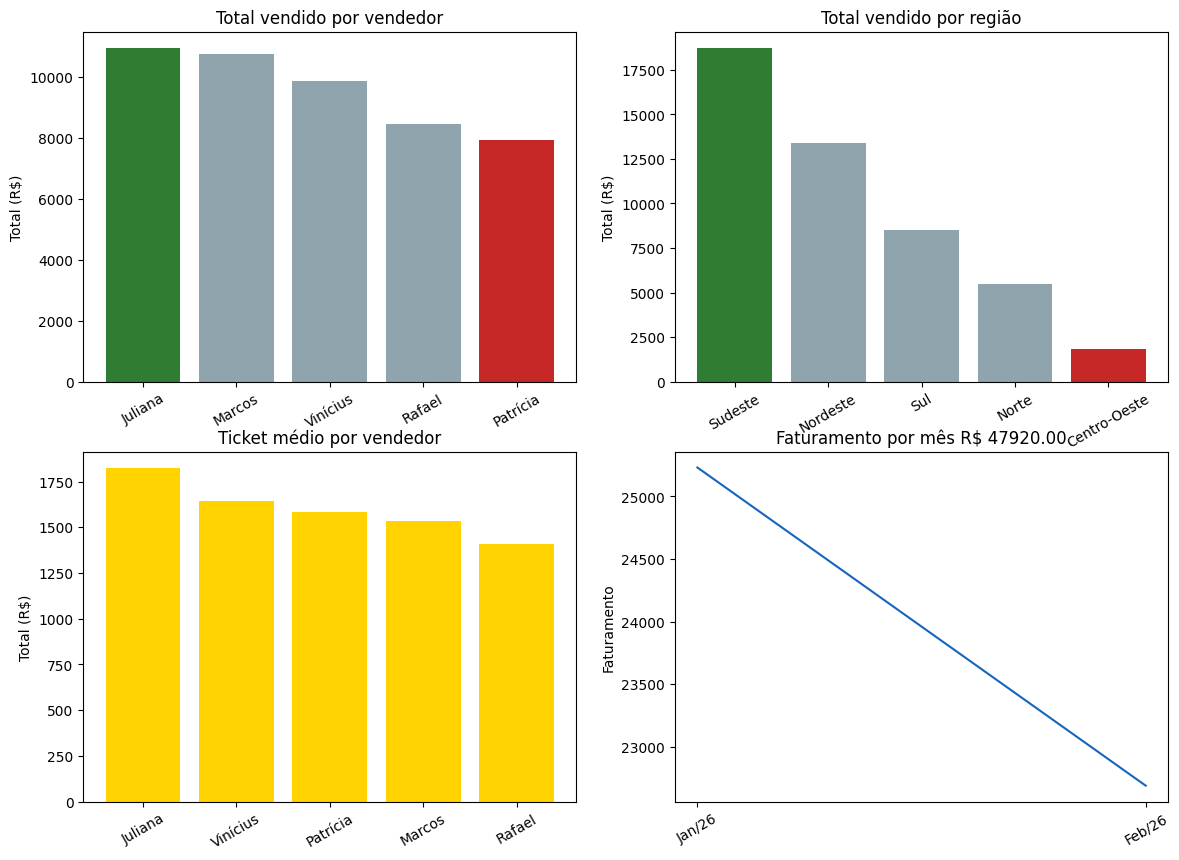

In [19]:
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize = (14,10))

### Gráfico 1 total vendido por vendedor
cores_vendedor = [ '#2E7D32' if v == melhor_vendedor
                             else '#C62828' if v == pior_vendedor
                                            else '#90A4AE' for v in total_por_vendedor.index ]

ax1.bar(total_por_vendedor.index, total_por_vendedor.values,color = cores_vendedor)
ax1.set_title('Total vendido por vendedor')
ax1.set_ylabel('Total (R$)')
ax1.tick_params(axis = 'x', rotation = 30)

### Gráfico 2 total vendido por região

cores_regiao = [ '#2E7D32' if r == melhor_regiao
                             else '#C62828' if r == pior_regiao
                                            else '#90A4AE' for r in total_por_regiao.index ]

ax2.bar(total_por_regiao.index, total_por_regiao.values,color = cores_regiao)
ax2.set_title('Total vendido por região')
ax2.set_ylabel('Total (R$)')
ax2.tick_params(axis = 'x', rotation = 30)

### Gráfico 3 Ticket médio por vendedor

ax3.bar(media_por_vendedor.index, media_por_vendedor.values,color = '#FFD200')
ax3.set_title('Ticket médio por vendedor')
ax3.set_ylabel('Total (R$)')
ax3.tick_params(axis = 'x', rotation = 30)

### Gráfico 4 Faturamento total por mês

ax4.plot(faturamento_por_mes.index, faturamento_por_mes.values,color = '#1565C0')
ax4.set_title(f"Faturamento por mês R$ {faturamento_total:.2f}")
ax4.set_ylabel("Faturamento")
ax4.tick_params(axis = 'x', rotation = 30)